# Full Gowalla EDA with Figshare POI Metadata

This notebook analyzes the full SNAP Gowalla check-in dataset and enriches it with Gowalla POI metadata from Figshare.

The SNAP check-in file contains:

- `userid`
- `datetime`
- `lat`
- `lng`
- `placeid`

It does not contain POI names or categories.

Therefore, we use Figshare Gowalla metadata:

- `gowalla_spots_subset1.csv` for categories;
- `gowalla_spots_subset2.csv` for POI names and city/state when available;
- `gowalla_category_structure.json` to inspect the original Gowalla category hierarchy.

The analysis is performed for the full Gowalla dataset, not only New York.

In [ ]:
from pathlib import Path
import os
import json
import zipfile
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

IN_COLAB = Path("/content").exists()

DATA_DIR = Path("/content/data") if IN_COLAB else Path("data")
OUT_DIR = Path("/content/outputs") if IN_COLAB else Path("outputs")
FIG_DIR = OUT_DIR / "figures"

for p in [DATA_DIR, OUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())

DATA_DIR: /content/data
OUT_DIR: /content/outputs


In [ ]:
FULL_GOWALLA_SNAP_URL = "https://snap.stanford.edu/data/loc-gowalla_totalCheckins.txt.gz"
FULL_GOWALLA_FILENAME = "loc-gowalla_totalCheckins.txt.gz"

# Use a smaller number for debugging, e.g. 500_000.
# Use None for the full dataset.
MAX_FULL_GOWALLA_ROWS = None


def download_file(url: str, target: Path) -> Path:
    import urllib.request

    target.parent.mkdir(parents=True, exist_ok=True)

    if target.exists() and target.stat().st_size > 0:
        print(f"Already exists: {target} ({target.stat().st_size / 1024 / 1024:.2f} MB)")
        return target

    print(f"Downloading to {target} ...")
    urllib.request.urlretrieve(url, target)
    print(f"Downloaded: {target} ({target.stat().st_size / 1024 / 1024:.2f} MB)")
    return target


snap_path = download_file(FULL_GOWALLA_SNAP_URL, DATA_DIR / FULL_GOWALLA_FILENAME)

raw_df = pd.read_csv(
    snap_path,
    sep="\t",
    header=None,
    names=["userid", "datetime", "lat", "lng", "placeid"],
    compression="infer",
    nrows=MAX_FULL_GOWALLA_ROWS,
    dtype={
        "userid": "int64",
        "placeid": "int64",
        "lat": "float32",
        "lng": "float32",
    },
)

raw_df["datetime"] = pd.to_datetime(raw_df["datetime"], errors="coerce", utc=True)

print("Raw shape:", raw_df.shape)
display(raw_df.head())

Downloaded: /content/data/loc-gowalla_totalCheckins.txt.gz (100.58 MB)
Raw shape: (6442892, 5)


,userid,datetime,lat,lng,placeid
0,0,2010-10-19 23:55:27+00:00,30.2359,-97.7951,22847
1,0,2010-10-18 22:17:43+00:00,30.2691,-97.7494,420315
2,0,2010-10-17 23:42:03+00:00,30.2557,-97.7634,316637
3,0,2010-10-17 19:26:05+00:00,30.2634,-97.7576,16516
4,0,2010-10-16 18:50:42+00:00,30.2743,-97.7405,5535878


In [ ]:
quality_summary = pd.DataFrame({
    "metric": [
        "checkins",
        "unique_users",
        "unique_pois",
        "date_min",
        "date_max",
        "missing_datetime",
        "missing_lat_lng",
        "duplicate_rows",
        "invalid_lat",
        "invalid_lng",
    ],
    "value": [
        len(raw_df),
        raw_df["userid"].nunique(),
        raw_df["placeid"].nunique(),
        raw_df["datetime"].min(),
        raw_df["datetime"].max(),
        raw_df["datetime"].isna().sum(),
        raw_df[["lat", "lng"]].isna().any(axis=1).sum(),
        raw_df.duplicated().sum(),
        (~raw_df["lat"].between(-90, 90)).sum(),
        (~raw_df["lng"].between(-180, 180)).sum(),
    ],
})

display(quality_summary)

,metric,value
0,checkins,6442892
1,unique_users,107092
2,unique_pois,1280969
3,date_min,2009-02-04 05:17:38+00:00
4,date_max,2010-10-23 05:22:06+00:00
5,missing_datetime,0
6,missing_lat_lng,0
7,duplicate_rows,601
8,invalid_lat,29
9,invalid_lng,0


In [ ]:
df = raw_df.dropna(subset=["datetime", "lat", "lng", "userid", "placeid"]).copy()
df = df[df["lat"].between(-90, 90) & df["lng"].between(-180, 180)]
df = df.drop_duplicates()
df = df.sort_values(["userid", "datetime", "placeid"]).reset_index(drop=True)

place_base = (
    df.groupby("placeid")
    .agg(
        checkins=("userid", "size"),
        users=("userid", "nunique"),
        lat_from_checkins=("lat", "median"),
        lng_from_checkins=("lng", "median"),
        first_seen=("datetime", "min"),
        last_seen=("datetime", "max"),
    )
    .reset_index()
    .sort_values("checkins", ascending=False)
)

display(place_base.head(20))

print("Clean check-ins:", len(df))
print("Unique POIs:", place_base["placeid"].nunique())

,placeid,checkins,users,lat_from_checkins,lng_from_checkins,first_seen,last_seen
38787,55033,5811,2353,59.3302,18.0581,2009-10-25 13:57:07+00:00,2010-10-22 17:47:25+00:00
8726,19542,5662,2631,37.6164,-122.3861,2009-09-11 12:05:40+00:00,2010-10-22 00:52:22+00:00
328,9410,4713,2157,30.2016,-97.6671,2009-03-18 16:17:58+00:00,2010-10-22 16:44:01+00:00
1082,10259,4083,2027,32.8975,-97.0404,2009-03-27 14:32:40+00:00,2010-10-22 14:21:06+00:00
41870,58725,3476,1791,59.6501,17.9323,2009-10-23 14:41:22+00:00,2010-10-22 14:24:35+00:00
4624,14470,3420,1757,33.6386,-84.4371,2009-04-23 17:27:29+00:00,2010-10-21 19:30:09+00:00
11660,23256,3416,1615,39.8495,-104.6739,2009-08-02 02:46:25+00:00,2010-10-21 23:56:01+00:00
185,9246,3401,1505,30.2636,-97.7396,2009-03-13 18:04:07+00:00,2010-10-22 06:31:31+00:00
1017,10190,3396,1898,33.9435,-118.4072,2009-09-12 23:10:11+00:00,2010-10-22 12:21:55+00:00
180,9241,3322,961,30.2707,-97.7537,2009-03-15 15:31:57+00:00,2010-10-22 00:47:40+00:00


Clean check-ins: 6442262
Unique POIs: 1280956


In [ ]:
FIGSHARE_ARTICLE_ID = 22126586

FIGSHARE_FILES = {
    "gowalla_spots_subset1.csv": "https://ndownloader.figshare.com/files/39334352",
    "gowalla_spots_subset2.csv": "https://ndownloader.figshare.com/files/39334355",
    "gowalla_category_structure.json": "https://ndownloader.figshare.com/files/39334343",
}

downloaded_metadata_paths = {}

for file_name, url in FIGSHARE_FILES.items():
    path = download_file(url, DATA_DIR / file_name)
    downloaded_metadata_paths[file_name] = path

downloaded_metadata_paths

Downloaded: /content/data/gowalla_spots_subset1.csv (327.39 MB)
Downloaded: /content/data/gowalla_spots_subset2.csv (7.82 MB)
Downloaded: /content/data/gowalla_category_structure.json (0.09 MB)


{'gowalla_spots_subset1.csv': PosixPath('/content/data/gowalla_spots_subset1.csv'),
 'gowalla_spots_subset2.csv': PosixPath('/content/data/gowalla_spots_subset2.csv'),
 'gowalla_category_structure.json': PosixPath('/content/data/gowalla_category_structure.json')}

In [ ]:
def normalize_id_series(s):
    return pd.to_numeric(s, errors="coerce").astype("Int64")


# -----------------------------
# Figshare spots subset1:
# categories and spot-level counts
# -----------------------------

spots1_usecols = [
    "id",
    "lat",
    "lng",
    "checkins_count",
    "users_count",
    "spot_categories",
]

figshare_spots1 = pd.read_csv(
    downloaded_metadata_paths["gowalla_spots_subset1.csv"],
    usecols=spots1_usecols,
    low_memory=False,
)

figshare_spots1 = figshare_spots1.rename(columns={"id": "placeid"})

figshare_spots1["placeid"] = normalize_id_series(figshare_spots1["placeid"])
figshare_spots1["lat"] = pd.to_numeric(figshare_spots1["lat"], errors="coerce").astype("float32")
figshare_spots1["lng"] = pd.to_numeric(figshare_spots1["lng"], errors="coerce").astype("float32")

# Keep only POIs that appear in SNAP check-ins to reduce memory.
snap_place_ids = pd.Index(place_base["placeid"].astype("int64").unique())
figshare_spots1 = figshare_spots1[figshare_spots1["placeid"].isin(snap_place_ids)].copy()

figshare_spots1["category_id"] = (
    figshare_spots1["spot_categories"]
    .astype(str)
    .str.extract(r"/categories/(\d+)", expand=False)
)

figshare_spots1["category_name"] = (
    figshare_spots1["spot_categories"]
    .astype(str)
    .str.extract(r"'name':\s*'([^']+)'", expand=False)
)

figshare_spots1_meta = figshare_spots1[[
    "placeid",
    "lat",
    "lng",
    "checkins_count",
    "users_count",
    "category_id",
    "category_name",
]].copy()

figshare_spots1_meta = figshare_spots1_meta.dropna(subset=["placeid"])
figshare_spots1_meta["placeid"] = figshare_spots1_meta["placeid"].astype("int64")

print("figshare_spots1_meta:", figshare_spots1_meta.shape)
display(figshare_spots1_meta.head())


# -----------------------------
# Figshare spots subset2:
# POI names and city_state
# -----------------------------

figshare_spots2 = pd.read_csv(
    downloaded_metadata_paths["gowalla_spots_subset2.csv"],
    encoding="latin1",
    low_memory=False,
)

figshare_spots2 = figshare_spots2.rename(columns={
    "id": "placeid",
    "name": "spotname",
})

figshare_spots2["placeid"] = normalize_id_series(figshare_spots2["placeid"])
figshare_spots2["lat"] = pd.to_numeric(figshare_spots2["lat"], errors="coerce").astype("float32")
figshare_spots2["lng"] = pd.to_numeric(figshare_spots2["lng"], errors="coerce").astype("float32")

figshare_spots2_meta = (
    figshare_spots2[["placeid", "lat", "lng", "spotname", "city_state"]]
    .dropna(subset=["placeid"])
    .drop_duplicates(subset=["placeid"])
    .copy()
)

figshare_spots2_meta["placeid"] = figshare_spots2_meta["placeid"].astype("int64")

print("figshare_spots2_meta:", figshare_spots2_meta.shape)
display(figshare_spots2_meta.head())

del figshare_spots1, figshare_spots2

figshare_spots1_meta: (1240257, 7)


,placeid,lat,lng,checkins_count,users_count,category_id,category_name
0,8904,39.0523,-94.6075,114,21,89,Craftsman
1,8932,32.9277,-97.2544,67,48,17,BBQ
2,8936,39.0533,-94.5920,75,46,103,Theatre
3,8938,39.0528,-94.5903,438,94,1,Coffee Shop
4,8947,37.3319,-122.0296,3100,1186,121,Corporate Office


figshare_spots2_meta: (120958, 5)


,placeid,lat,lng,spotname,city_state
0,9813,36.6315,-121.9120,Pacific Ocean,"Seaside, CA"
1,11981,40.6902,-74.0455,Refreshment Park,"New York, NY"
2,12455,36.6420,-93.2849,Mickey Gilley Theatre,"Branson, MO"
4,13810,42.5489,-82.9028,Jaword,"Clinton, MI"
6,14800,42.4412,-82.9059,Lax field,"Grosse Pointe, MI"


In [ ]:
category_coverage_pois = place_base["placeid"].isin(figshare_spots1_meta["placeid"]).mean()

category_coverage_checkins = (
    place_base.loc[
        place_base["placeid"].isin(figshare_spots1_meta["placeid"]),
        "checkins"
    ].sum()
    / place_base["checkins"].sum()
)

name_coverage_pois = place_base["placeid"].isin(figshare_spots2_meta["placeid"]).mean()

name_coverage_checkins = (
    place_base.loc[
        place_base["placeid"].isin(figshare_spots2_meta["placeid"]),
        "checkins"
    ].sum()
    / place_base["checkins"].sum()
)

metadata_coverage = pd.DataFrame({
    "metadata_field": ["category", "spotname"],
    "poi_coverage": [category_coverage_pois, name_coverage_pois],
    "checkin_coverage": [category_coverage_checkins, name_coverage_checkins],
})

display(metadata_coverage)

,metadata_field,poi_coverage,checkin_coverage
0,category,0.9682,0.9730
1,spotname,0.0053,0.0024


In [ ]:
poi_metadata = place_base.merge(
    figshare_spots1_meta[[
        "placeid",
        "category_id",
        "category_name",
        "checkins_count",
        "users_count",
    ]],
    on="placeid",
    how="left",
)

poi_metadata = poi_metadata.merge(
    figshare_spots2_meta[[
        "placeid",
        "spotname",
        "city_state",
    ]],
    on="placeid",
    how="left",
)

poi_metadata["category_name"] = poi_metadata["category_name"].fillna("Unknown")
poi_metadata["spotname"] = poi_metadata["spotname"].fillna("Unknown")

display(poi_metadata.head(20))

df = df.merge(
    poi_metadata[[
        "placeid",
        "category_id",
        "category_name",
        "spotname",
        "city_state",
    ]],
    on="placeid",
    how="left",
)

df["category_name"] = df["category_name"].fillna("Unknown").astype("category")
df["spotname"] = df["spotname"].fillna("Unknown")
df["city_state"] = df["city_state"].fillna("Unknown")

print("Enriched check-ins:", df.shape)
display(df.head())

,placeid,checkins,users,lat_from_checkins,lng_from_checkins,first_seen,last_seen,category_id,category_name,checkins_count,users_count,spotname,city_state
0,55033,5811,2353,59.3302,18.0581,2009-10-25 13:57:07+00:00,2010-10-22 17:47:25+00:00,95,Train Station,"30,935.0000","8,382.0000",Unknown,NaN
1,19542,5662,2631,37.6164,-122.3861,2009-09-11 12:05:40+00:00,2010-10-22 00:52:22+00:00,45,Airport,"25,706.0000","9,105.0000",Unknown,NaN
2,9410,4713,2157,30.2016,-97.6671,2009-03-18 16:17:58+00:00,2010-10-22 16:44:01+00:00,45,Airport,"25,489.0000","7,788.0000",Unknown,NaN
3,10259,4083,2027,32.8975,-97.0404,2009-03-27 14:32:40+00:00,2010-10-22 14:21:06+00:00,45,Airport,"25,384.0000","8,080.0000",Unknown,NaN
4,58725,3476,1791,59.6501,17.9323,2009-10-23 14:41:22+00:00,2010-10-22 14:24:35+00:00,45,Airport,"22,108.0000","7,849.0000",Unknown,NaN
5,14470,3420,1757,33.6386,-84.4371,2009-04-23 17:27:29+00:00,2010-10-21 19:30:09+00:00,45,Airport,"17,988.0000","7,248.0000",Unknown,NaN
6,23256,3416,1615,39.8495,-104.6739,2009-08-02 02:46:25+00:00,2010-10-21 23:56:01+00:00,45,Airport,"15,971.0000","6,338.0000",Unknown,NaN
7,9246,3401,1505,30.2636,-97.7396,2009-03-13 18:04:07+00:00,2010-10-22 06:31:31+00:00,243,Convention Center,"17,323.0000","6,511.0000",Unknown,NaN
8,10190,3396,1898,33.9435,-118.4072,2009-09-12 23:10:11+00:00,2010-10-22 12:21:55+00:00,45,Airport,"20,449.0000","8,641.0000",Unknown,NaN
9,9241,3322,961,30.2707,-97.7537,2009-03-15 15:31:57+00:00,2010-10-22 00:47:40+00:00,422,Whole Foods,"14,967.0000","3,498.0000",Unknown,NaN


Enriched check-ins: (6442262, 9)


,userid,datetime,lat,lng,placeid,category_id,category_name,spotname,city_state
0,0,2010-05-22 02:49:04+00:00,30.2489,-97.7496,608105,155,Pizza,Unknown,Unknown
1,0,2010-05-22 17:50:55+00:00,39.2974,-94.7160,8977,45,Airport,Unknown,Unknown
2,0,2010-05-22 19:13:12+00:00,38.9852,-94.6059,18574,17,BBQ,Unknown,Unknown
3,0,2010-05-23 16:50:50+00:00,39.0935,-94.5932,17269,16,American,Unknown,Unknown
4,0,2010-05-23 17:51:57+00:00,39.0933,-94.5939,1161876,912,Snow Cones,Unknown,Unknown


In [ ]:
# Inspect Figshare Gowalla category hierarchy.
# This file is not required for the main join, but it documents the original Gowalla category structure.

category_structure_path = downloaded_metadata_paths["gowalla_category_structure.json"]

with open(category_structure_path, "r", encoding="utf-8") as f:
    category_structure = json.load(f)

def extract_category_rows(obj, parent_name=None, parent_id=None, depth=0):
    rows = []

    if isinstance(obj, dict):
        name = obj.get("name")
        url = obj.get("url")
        category_id = None

        if isinstance(url, str):
            match = re.search(r"/categories/(\d+)", url)
            if match:
                category_id = match.group(1)

        if name is not None or category_id is not None:
            rows.append({
                "category_id": category_id,
                "category_name": name,
                "parent_category_id": parent_id,
                "parent_category_name": parent_name,
                "depth": depth,
                "url": url,
            })

            next_parent_name = name
            next_parent_id = category_id
            next_depth = depth + 1
        else:
            next_parent_name = parent_name
            next_parent_id = parent_id
            next_depth = depth

        for value in obj.values():
            if isinstance(value, (dict, list)):
                rows.extend(
                    extract_category_rows(
                        value,
                        parent_name=next_parent_name,
                        parent_id=next_parent_id,
                        depth=next_depth,
                    )
                )

    elif isinstance(obj, list):
        for item in obj:
            rows.extend(
                extract_category_rows(
                    item,
                    parent_name=parent_name,
                    parent_id=parent_id,
                    depth=depth,
                )
            )

    return rows

category_hierarchy = pd.DataFrame(extract_category_rows(category_structure))

if len(category_hierarchy):
    category_hierarchy = category_hierarchy.drop_duplicates(
        subset=["category_id", "category_name", "parent_category_id", "parent_category_name", "depth"]
    )

print("Category hierarchy rows:", len(category_hierarchy))
display(category_hierarchy.head(30))

if len(category_hierarchy):
    display(
        category_hierarchy
        .groupby("depth")
        .size()
        .reset_index(name="categories")
    )
else:
    print("No category hierarchy rows were extracted. Raw JSON preview:")
    display(category_structure)

Category hierarchy rows: 269


,category_id,category_name,parent_category_id,parent_category_name,depth,url
0,934,Community,None,None,0,/categories/934
1,133,Campus Spot,934,Community,1,/categories/133
2,135,Administration,133,Campus Spot,2,/categories/135
3,138,Campus Commons,133,Campus Spot,2,/categories/138
4,153,Campus - Other,133,Campus Spot,2,/categories/153
5,139,Dormitory,133,Campus Spot,2,/categories/139
6,140,Frat House,133,Campus Spot,2,/categories/140
7,141,Hall,133,Campus Spot,2,/categories/141
8,142,Lab,133,Campus Spot,2,/categories/142
9,143,Rec Center,133,Campus Spot,2,/categories/143


,depth,categories
0,0,7
1,1,134
2,2,128


,category_name,checkins
0,Corporate Office,320180
1,Coffee Shop,186577
2,Grocery,150685
3,Apartment,148129
4,Train Station,141959
5,Mall,128538
6,Gas & Automotive,127327
7,American,126247
8,Asian,124225
9,Mexican,121371


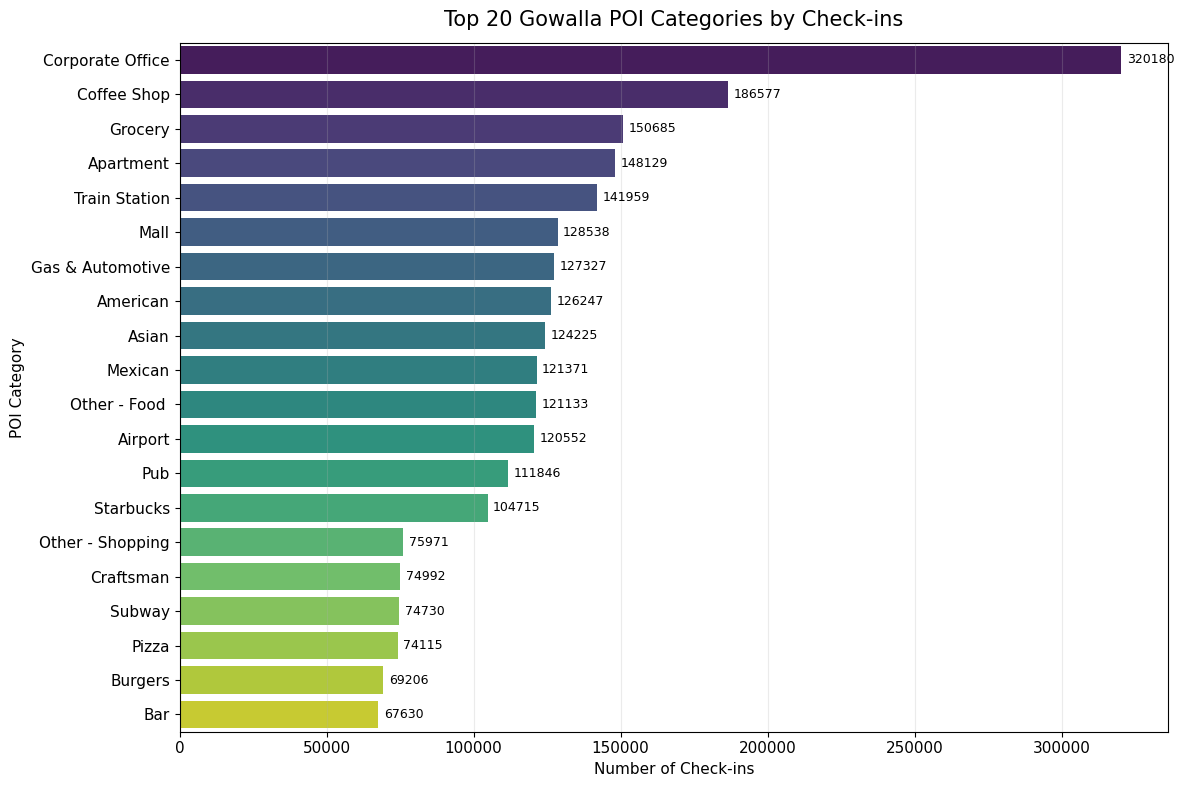

In [ ]:
# Top POI categories by number of check-ins.
# We use observed=True because category_name is a pandas categorical column.
# Without it, pandas/seaborn can keep unused category levels and produce an unreadable plot.

top_n = 20

top_category_counts = (
    df.loc[df["category_name"].astype(str) != "Unknown"]
    .groupby("category_name", observed=True)
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index(name="checkins")
)

top_category_counts["category_name"] = top_category_counts["category_name"].astype(str)

display(top_category_counts)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=top_category_counts,
    y="category_name",
    x="checkins",
    palette="viridis",
    ax=ax,
)

ax.set_title(f"Top {top_n} Gowalla POI Categories by Check-ins", fontsize=15, pad=12)
ax.set_xlabel("Number of Check-ins")
ax.set_ylabel("POI Category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4, fontsize=9)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "top_categories_by_checkins.png", dpi=160, bbox_inches="tight")
plt.show()

,placeid,poi_label,checkins,users,category_name,spotname,city_state,lat_from_checkins,lng_from_checkins
0,55033,placeid 55033 | Train Station,5811,2353,Train Station,Unknown,NaN,59.3302,18.0581
1,19542,placeid 19542 | Airport,5662,2631,Airport,Unknown,NaN,37.6164,-122.3861
2,9410,placeid 9410 | Airport,4713,2157,Airport,Unknown,NaN,30.2016,-97.6671
3,10259,placeid 10259 | Airport,4083,2027,Airport,Unknown,NaN,32.8975,-97.0404
4,58725,placeid 58725 | Airport,3476,1791,Airport,Unknown,NaN,59.6501,17.9323
5,14470,placeid 14470 | Airport,3420,1757,Airport,Unknown,NaN,33.6386,-84.4371
6,23256,placeid 23256 | Airport,3416,1615,Airport,Unknown,NaN,39.8495,-104.6739
7,9246,placeid 9246 | Convention Center,3401,1505,Convention Center,Unknown,NaN,30.2636,-97.7396
8,10190,placeid 10190 | Airport,3396,1898,Airport,Unknown,NaN,33.9435,-118.4072
9,9241,placeid 9241 | Whole Foods,3322,961,Whole Foods,Unknown,NaN,30.2707,-97.7537


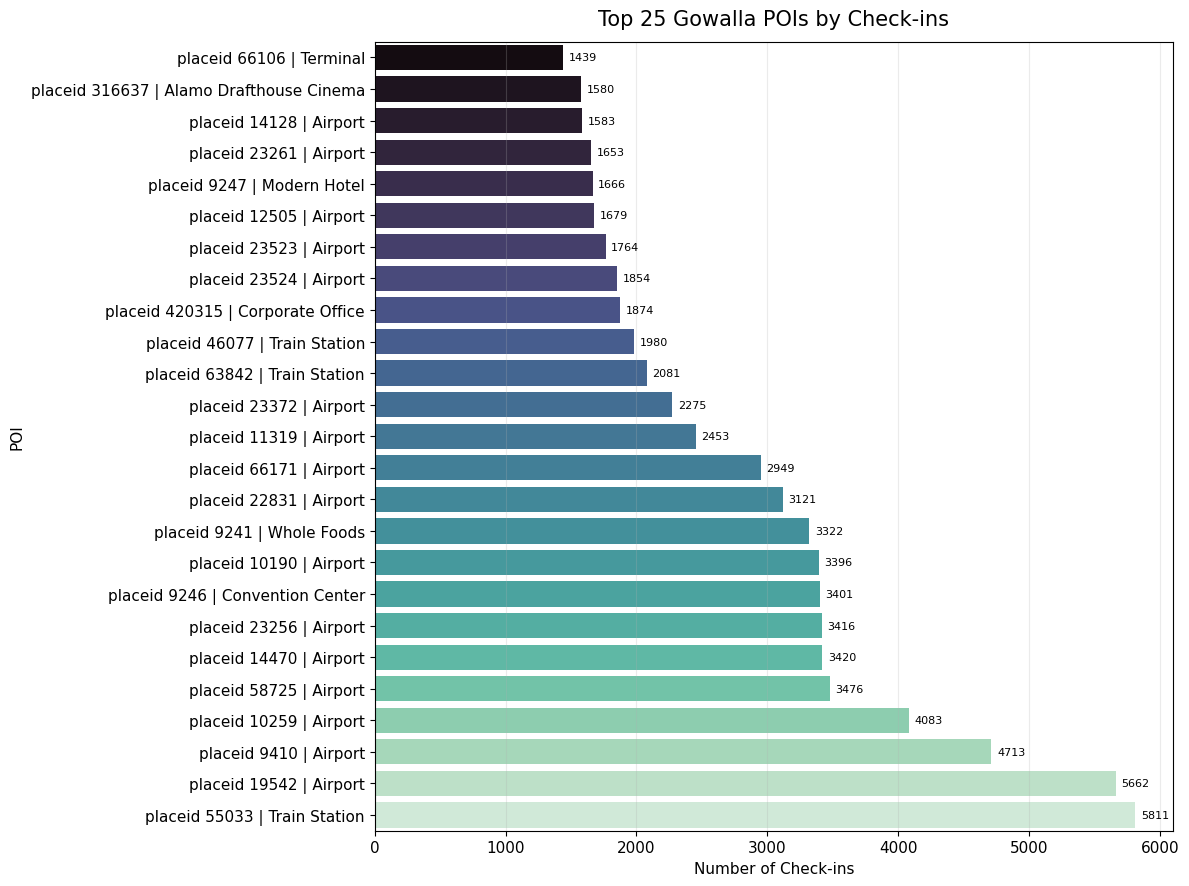

In [ ]:
# Top individual POIs by number of check-ins.
# Many spot names are unavailable, so placeid is used as a stable fallback label.

top_n = 25

top_pois = poi_metadata.sort_values("checkins", ascending=False).head(top_n).copy()

top_pois["poi_label"] = np.where(
    top_pois["spotname"].astype(str).ne("Unknown"),
    top_pois["spotname"].astype(str),
    "placeid " + top_pois["placeid"].astype(str),
)

top_pois["poi_label"] = (
    top_pois["poi_label"].str.slice(0, 42)
    + " | "
    + top_pois["category_name"].astype(str).str.slice(0, 24)
)

display(top_pois[[
    "placeid",
    "poi_label",
    "checkins",
    "users",
    "category_name",
    "spotname",
    "city_state",
    "lat_from_checkins",
    "lng_from_checkins",
]].head(top_n))

fig, ax = plt.subplots(figsize=(12, 9))

sns.barplot(
    data=top_pois.sort_values("checkins", ascending=True),
    x="checkins",
    y="poi_label",
    palette="mako",
    ax=ax,
)

ax.set_title(f"Top {top_n} Gowalla POIs by Check-ins", fontsize=15, pad=12)
ax.set_xlabel("Number of Check-ins")
ax.set_ylabel("POI")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4, fontsize=8)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "top_pois_by_checkins.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
# Add time-based features for temporal EDA.

df["date"] = df["datetime"].dt.date
df["month"] = df["datetime"].dt.to_period("M").astype(str)
df["weekday"] = df["datetime"].dt.day_name()
df["weekday_num"] = df["datetime"].dt.dayofweek
df["hour"] = df["datetime"].dt.hour

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]

def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    if 12 <= hour < 17:
        return "Afternoon"
    if 17 <= hour < 22:
        return "Evening"
    return "Night"

df["time_of_day"] = df["hour"].map(time_of_day)

display(df[[
    "userid",
    "datetime",
    "date",
    "month",
    "weekday",
    "hour",
    "time_of_day",
    "placeid",
    "category_name",
]].head())

,userid,datetime,date,month,weekday,hour,time_of_day,placeid,category_name
0,0,2010-05-22 02:49:04+00:00,2010-05-22,2010-05,Saturday,2,Night,608105,Pizza
1,0,2010-05-22 17:50:55+00:00,2010-05-22,2010-05,Saturday,17,Evening,8977,Airport
2,0,2010-05-22 19:13:12+00:00,2010-05-22,2010-05,Saturday,19,Evening,18574,BBQ
3,0,2010-05-23 16:50:50+00:00,2010-05-23,2010-05,Sunday,16,Afternoon,17269,American
4,0,2010-05-23 17:51:57+00:00,2010-05-23,2010-05,Sunday,17,Evening,1161876,Snow Cones


,date,checkins
0,2009-02-04,1
1,2009-02-05,1
2,2009-02-17,2
3,2009-02-18,1
4,2009-02-23,2


,month,checkins
0,2009-02,7
1,2009-03,873
2,2009-04,567
3,2009-05,998
4,2009-06,675
5,2009-07,1102
6,2009-08,1442
7,2009-09,7641
8,2009-10,37884
9,2009-11,86863


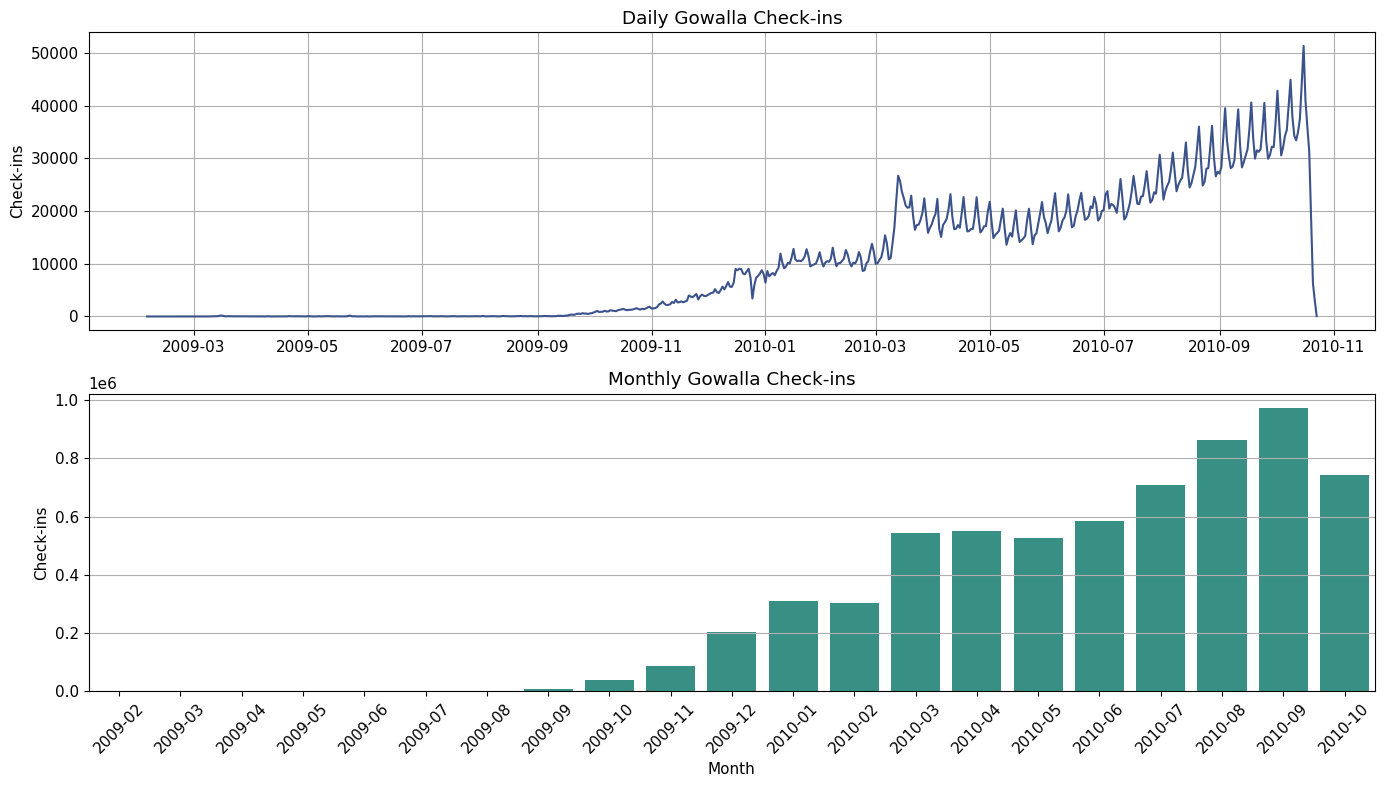

In [ ]:
# Overall activity over time.

daily_checkins = df.groupby("date").size().reset_index(name="checkins")
monthly_checkins = df.groupby("month").size().reset_index(name="checkins")

display(daily_checkins.head())
display(monthly_checkins)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

sns.lineplot(data=daily_checkins, x="date", y="checkins", ax=axes[0], color="#3b528b")
axes[0].set_title("Daily Gowalla Check-ins")
axes[0].set_xlabel("")
axes[0].set_ylabel("Check-ins")

sns.barplot(data=monthly_checkins, x="month", y="checkins", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Monthly Gowalla Check-ins")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Check-ins")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / "checkins_over_time.png", dpi=160, bbox_inches="tight")
plt.show()

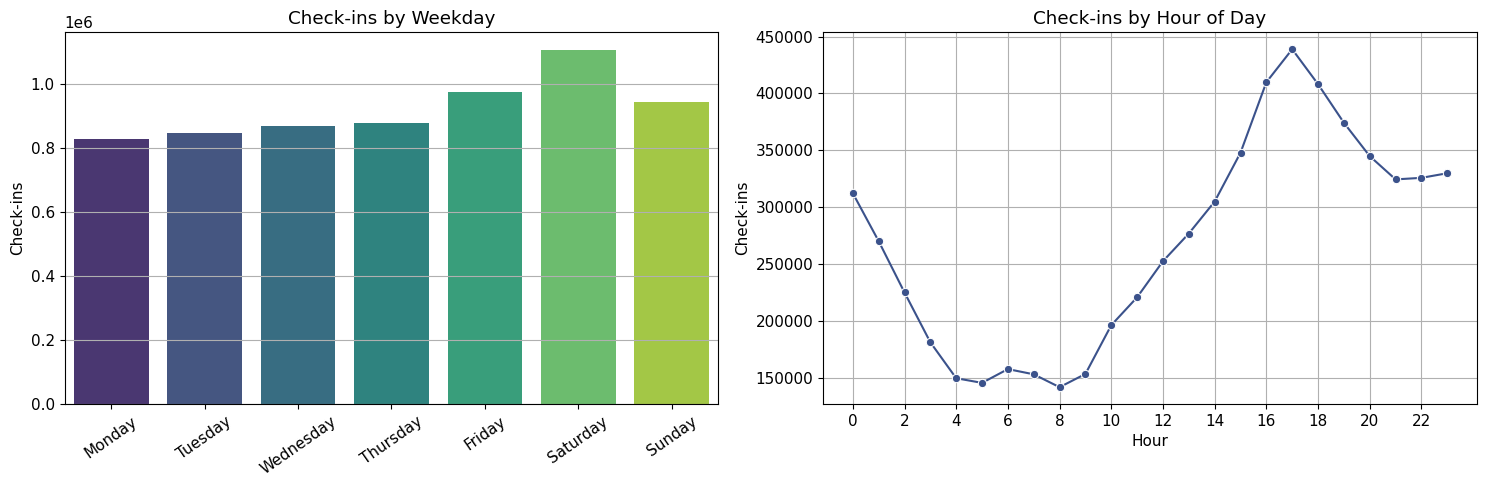

In [ ]:
# Check-in distribution by weekday and hour.

weekday_counts = (
    df.groupby(["weekday_num", "weekday"])
    .size()
    .reset_index(name="checkins")
    .sort_values("weekday_num")
)

hour_counts = df.groupby("hour").size().reset_index(name="checkins")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=weekday_counts, x="weekday", y="checkins", palette="viridis", ax=axes[0])
axes[0].set_title("Check-ins by Weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Check-ins")
axes[0].tick_params(axis="x", rotation=35)

sns.lineplot(data=hour_counts, x="hour", y="checkins", marker="o", ax=axes[1], color="#3b528b")
axes[1].set_title("Check-ins by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Check-ins")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(FIG_DIR / "weekday_hour_patterns.png", dpi=160, bbox_inches="tight")
plt.show()

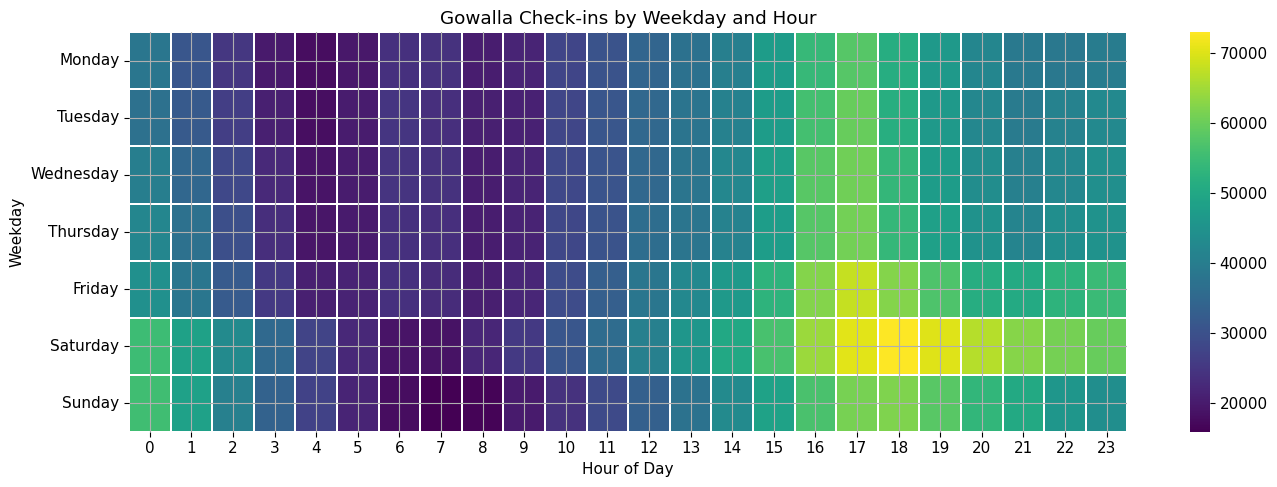

In [ ]:
# Heatmap of check-in intensity by weekday and hour.

weekday_hour = (
    df.groupby(["weekday", "hour"])
    .size()
    .reset_index(name="checkins")
)

weekday_hour_pivot = (
    weekday_hour
    .pivot(index="weekday", columns="hour", values="checkins")
    .reindex(weekday_order)
    .fillna(0)
)

plt.figure(figsize=(14, 5))
sns.heatmap(
    weekday_hour_pivot,
    cmap="viridis",
    linewidths=0.2,
    linecolor="white",
)

plt.title("Gowalla Check-ins by Weekday and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")

plt.tight_layout()
plt.savefig(FIG_DIR / "weekday_hour_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
category_name,,,,,,,,,,,,,,,,,,,,,,,,
Corporate Office,6594,5918,4867,4061,4309,9083,20069,22098,17452,13235,13288,15015,19436,21864,21117,19635,18756,17200,14887,13251,11475,10234,8872,7464
Coffee Shop,5718,4925,4371,3615,2973,3434,4309,4777,4970,5953,8456,9230,11402,12862,12772,12644,12202,11397,10087,9599,9048,8044,7346,6443
Grocery,8095,6651,4953,3506,2497,2191,2352,2445,2821,3284,4636,5120,5717,6324,7789,9668,10902,10715,9436,8393,7964,8184,8564,8478
Apartment,5106,4638,4412,4181,3787,3884,3545,3346,3065,3158,3646,4072,4739,5462,7445,8963,10507,11097,10867,10226,9866,8869,7299,5949
Train Station,2809,1890,1615,2138,3697,6569,9094,9143,6974,6270,6534,7139,7373,7599,8554,9990,10054,8455,6180,4623,3885,3959,3909,3506
Mall,4712,3887,3151,2438,2266,2386,2680,2887,3663,4860,6634,7615,7585,6961,6941,7508,8127,7739,6996,6615,6195,5837,5528,5327
Gas & Automotive,5574,4637,3811,3035,2669,2944,3031,2792,2604,2729,3181,3955,5471,6398,6962,7625,8070,8299,8051,7439,7279,7316,7128,6327
American,10892,9378,7638,5238,3430,2105,1157,806,514,529,890,1169,1639,2193,2672,4448,8969,11035,9704,8457,7249,6905,8572,10658
Asian,8132,7691,7005,6208,4881,4148,2377,1639,1655,2551,4102,4404,3863,2907,2415,3333,7040,9096,7998,7687,6344,5225,6093,7431


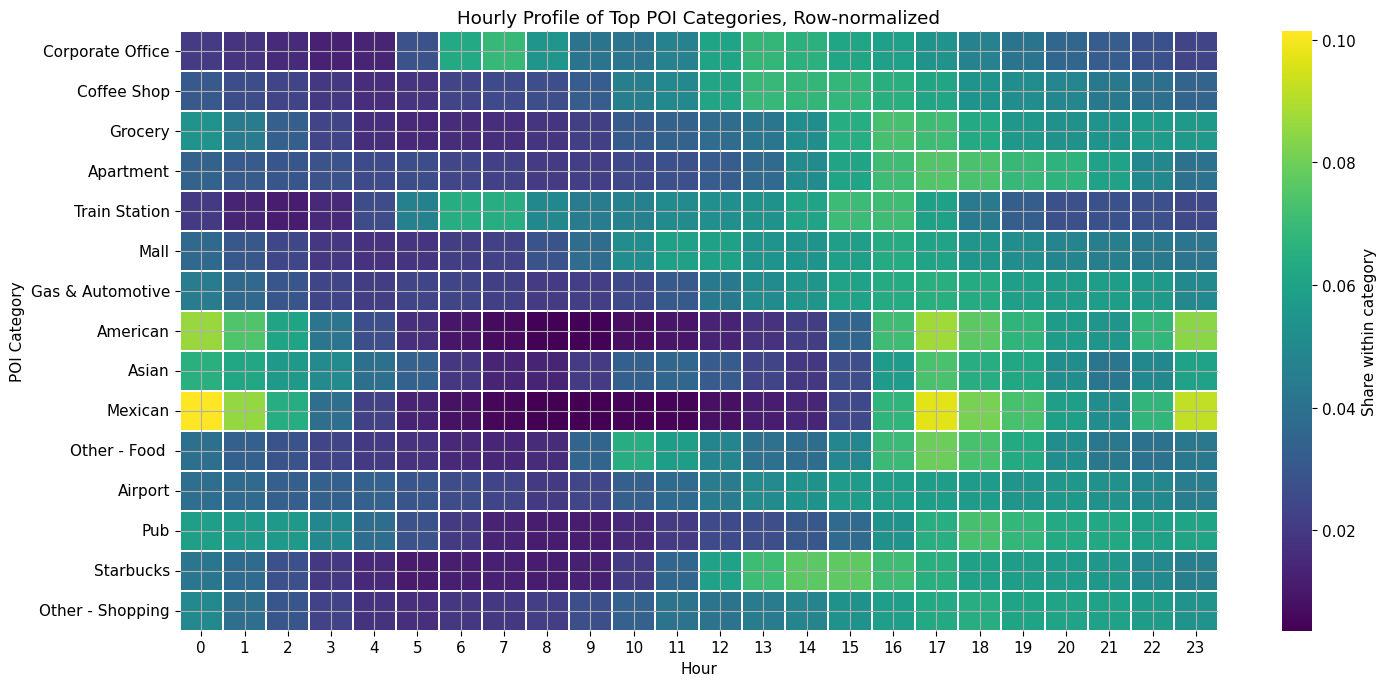

In [ ]:
# Hourly profile of top POI categories, row-normalized.
# Each row sums to 1, so this shows the daily rhythm within each category.

top_n = 15

category_hour_data = df.loc[
    df["category_name"].astype(str) != "Unknown",
    ["category_name", "hour"]
].copy()

category_hour_data["category_name"] = category_hour_data["category_name"].astype(str)

top_categories_hour = (
    category_hour_data["category_name"]
    .value_counts()
    .head(top_n)
    .index
)

category_hour_counts = (
    category_hour_data[category_hour_data["category_name"].isin(top_categories_hour)]
    .groupby(["category_name", "hour"])
    .size()
    .reset_index(name="checkins")
)

category_hour_pivot = (
    category_hour_counts
    .pivot_table(
        index="category_name",
        columns="hour",
        values="checkins",
        aggfunc="sum",
        observed=True,
    )
    .reindex(top_categories_hour)
    .reindex(columns=range(24), fill_value=0)
    .fillna(0)
)

category_hour_row_norm = category_hour_pivot.div(
    category_hour_pivot.sum(axis=1),
    axis=0,
)

display(category_hour_pivot.astype(int))

plt.figure(figsize=(15, 7))

sns.heatmap(
    category_hour_row_norm,
    cmap="viridis",
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Share within category"},
)

plt.title("Hourly Profile of Top POI Categories, Row-normalized")
plt.xlabel("Hour")
plt.ylabel("POI Category")

plt.tight_layout()
plt.savefig(FIG_DIR / "category_hour_row_normalized_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

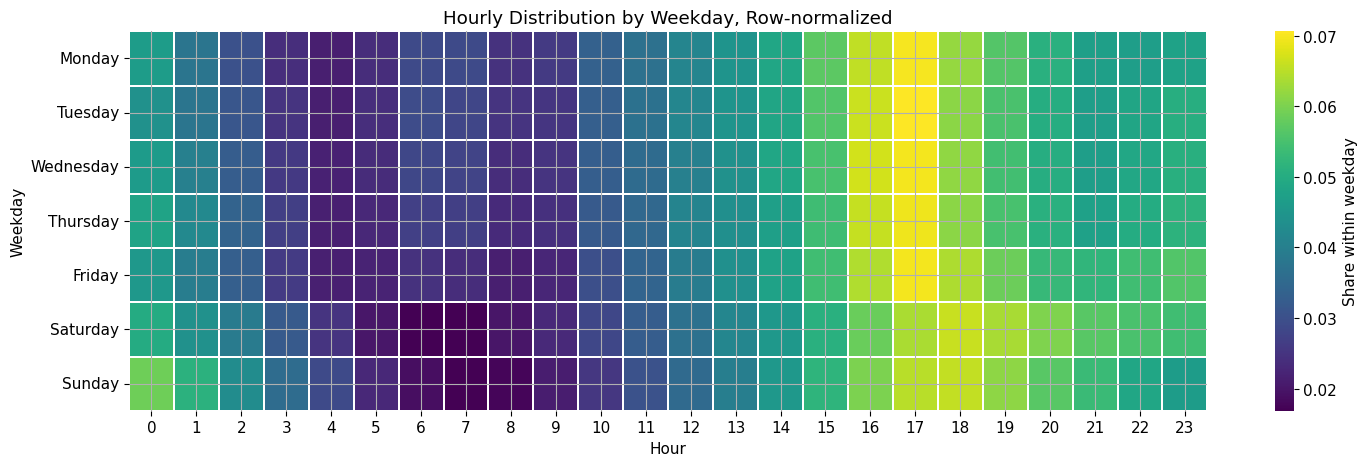

In [ ]:
# Hourly distribution by weekday, row-normalized.
# Each row sums to 1, so this shows the daily rhythm within each weekday.

weekday_hour_row_norm = weekday_hour_pivot.div(
    weekday_hour_pivot.sum(axis=1),
    axis=0,
)

plt.figure(figsize=(15, 4.8))

sns.heatmap(
    weekday_hour_row_norm,
    cmap="viridis",
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Share within weekday"},
)

plt.title("Hourly Distribution by Weekday, Row-normalized")
plt.xlabel("Hour")
plt.ylabel("Weekday")

plt.tight_layout()
plt.savefig(FIG_DIR / "weekday_hour_row_normalized_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

time_of_day,Morning,Afternoon,Evening,Night
category_name,,,,
Corporate Office,110240,100808,67047,42085
Coffee Shop,41129,61882,48175,35391
Grocery,22849,40400,44692,42744
Apartment,24716,37116,50925,35372
Train Station,51723,43570,27102,19564
Mall,30725,37122,33382,27309
Gas & Automotive,21236,34526,38384,33181
American,7170,19921,43350,55806
Asian,20876,19558,36350,47441


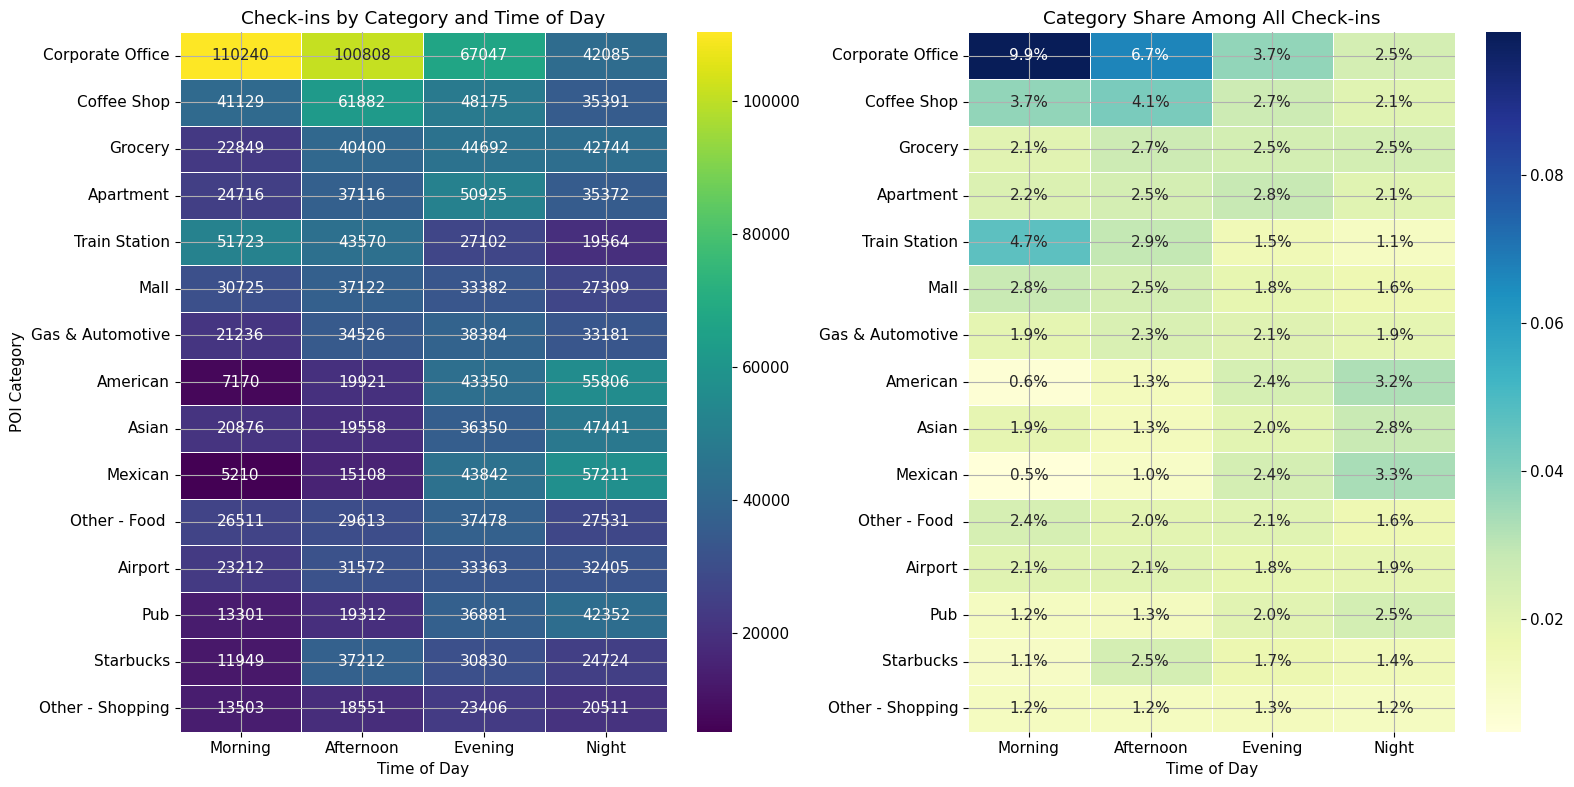

In [ ]:
# Which POI categories dominate in different parts of the day?
# Left: absolute check-ins for top categories.
# Right: share of ALL check-ins within each time-of-day period.

top_n = 15
time_order = ["Morning", "Afternoon", "Evening", "Night"]

category_time_data = df.loc[
    df["category_name"].astype(str) != "Unknown",
    ["time_of_day", "category_name"]
].copy()

category_time_data["category_name"] = category_time_data["category_name"].astype(str)

top_categories_for_time = (
    category_time_data["category_name"]
    .value_counts()
    .head(top_n)
    .index
)

category_time = (
    category_time_data
    .groupby(["category_name", "time_of_day"])
    .size()
    .reset_index(name="checkins")
)

category_time["time_of_day"] = pd.Categorical(
    category_time["time_of_day"],
    categories=time_order,
    ordered=True,
)

category_time_pivot_all = (
    category_time
    .pivot(index="category_name", columns="time_of_day", values="checkins")
    .reindex(columns=time_order)
    .fillna(0)
)

category_time_pivot = (
    category_time_pivot_all
    .reindex(index=top_categories_for_time)
    .fillna(0)
)

time_totals_all_categories = category_time_pivot_all.sum(axis=0)

category_time_share = category_time_pivot.div(time_totals_all_categories, axis=1)

display(category_time_pivot.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(
    category_time_pivot,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    annot=True,
    fmt=".0f",
    ax=axes[0],
)

axes[0].set_title("Check-ins by Category and Time of Day")
axes[0].set_xlabel("Time of Day")
axes[0].set_ylabel("POI Category")

sns.heatmap(
    category_time_share,
    cmap="YlGnBu",
    linewidths=0.4,
    linecolor="white",
    annot=True,
    fmt=".1%",
    ax=axes[1],
)

axes[1].set_title("Category Share Among All Check-ins")
axes[1].set_xlabel("Time of Day")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "categories_by_time_of_day_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
# Optional interactive map via folium.
# The map is constrained to one world copy to avoid repeated world tiles.

try:
    import folium
    from folium.plugins import HeatMap

    map_sample_size = min(100_000, len(df))

    map_sample = (
        df[["lat", "lng"]]
        .dropna()
        .sample(map_sample_size, random_state=RANDOM_STATE)
    )

    center = [
        float(map_sample["lat"].median()),
        float(map_sample["lng"].median()),
    ]

    world_bounds = [[-85, -180], [85, 180]]

    m = folium.Map(
        location=center,
        zoom_start=2,
        min_zoom=2,
        max_bounds=True,
        tiles=None,
        control_scale=True,
    )

    folium.TileLayer(
        tiles="CartoDB positron",
        name="CartoDB positron",
        no_wrap=True,
        bounds=world_bounds,
    ).add_to(m)

    m.fit_bounds(world_bounds)

    HeatMap(
        map_sample[["lat", "lng"]].values.tolist(),
        radius=8,
        blur=12,
        min_opacity=0.20,
    ).add_to(m)

    map_path = OUT_DIR / "gowalla_global_checkin_heatmap.html"
    m.save(map_path)

    print("Saved interactive map to:", map_path)
    display(m)

except Exception as e:
    print("Folium map skipped:", repr(e))

Saved interactive map to: /content/outputs/gowalla_global_checkin_heatmap.html


,userid,checkins,unique_pois,unique_categories,active_days,first_seen,last_seen,activity_span_days,checkins_per_active_day
8461,10971,2175,1187,160,206,2010-01-05 13:51:06+00:00,2010-10-19 16:33:31+00:00,288,10.5583
696,776,2174,2064,233,65,2010-08-11 22:46:31+00:00,2010-10-21 22:18:49+00:00,71,33.4462
13554,18931,2150,631,134,216,2010-03-07 00:51:52+00:00,2010-10-21 06:43:04+00:00,229,9.9537
565,620,2125,549,94,124,2010-06-21 08:08:07+00:00,2010-10-22 03:36:44+00:00,123,17.1371
32884,49918,2125,787,155,200,2010-03-18 10:24:12+00:00,2010-10-13 09:33:59+00:00,209,10.6250
13671,19096,2100,1644,247,149,2010-02-23 23:29:08+00:00,2010-10-20 18:43:10+00:00,239,14.0940
2,2,2100,1870,210,45,2010-08-25 16:44:12+00:00,2010-10-21 00:03:50+00:00,57,46.6667
628,695,2075,976,185,193,2010-04-12 15:21:15+00:00,2010-10-22 01:11:52+00:00,193,10.7513
13812,19278,2075,490,117,132,2010-04-05 19:28:45+00:00,2010-10-18 08:13:32+00:00,196,15.7197
20,22,2050,1747,198,214,2009-10-06 03:23:30+00:00,2010-10-17 21:43:09+00:00,377,9.5794


,checkins,unique_pois,unique_categories,active_days,activity_span_days,checkins_per_active_day
count,"107,092.0000","107,092.0000","107,092.0000","107,092.0000","107,092.0000","107,092.0000"
mean,60.1563,37.1766,19.5538,25.3062,90.5101,2.0999
std,136.1705,85.7364,22.8110,34.6211,90.0469,3.2226
min,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
25%,7.0000,5.0000,5.0000,5.0000,17.0000,1.1905
50%,25.0000,17.0000,13.0000,14.0000,60.0000,1.5000
75%,56.0000,38.0000,25.0000,31.0000,144.0000,2.0000
90%,137.0000,81.0000,45.0000,63.0000,224.0000,3.0303
95%,225.0000,129.0000,62.0000,93.0000,274.0000,4.3860
99%,608.0000,340.0000,111.0000,173.0000,346.0000,12.5000


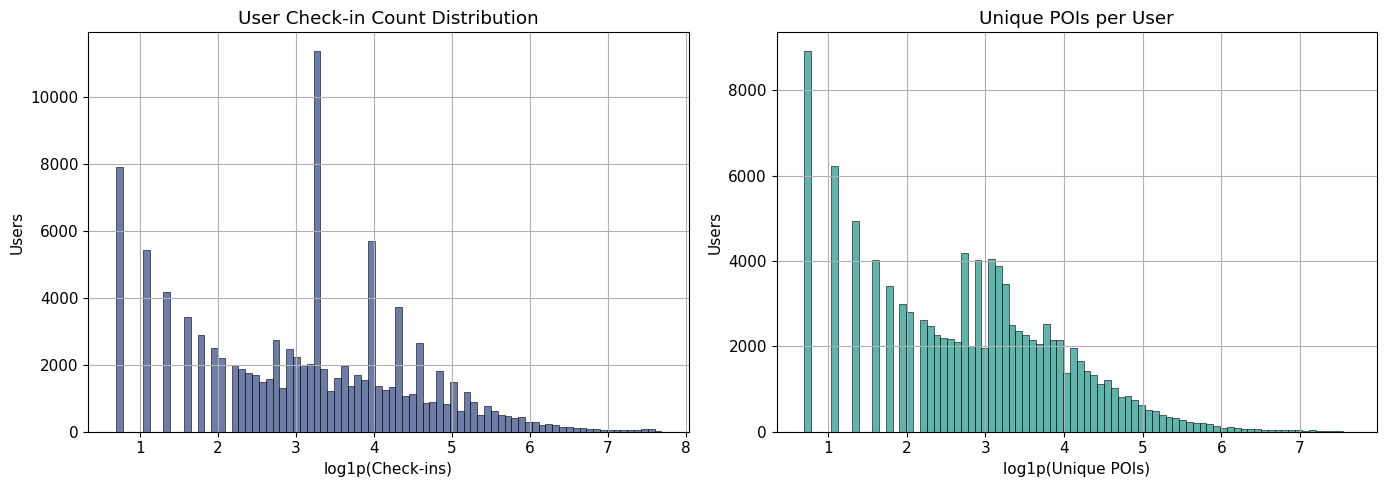

In [ ]:
# User-level activity summary.

if "date" not in df.columns:
    df["date"] = df["datetime"].dt.date

user_activity = (
    df.groupby("userid")
    .agg(
        checkins=("placeid", "size"),
        unique_pois=("placeid", "nunique"),
        unique_categories=("category_name", "nunique"),
        active_days=("date", "nunique"),
        first_seen=("datetime", "min"),
        last_seen=("datetime", "max"),
    )
    .reset_index()
)

user_activity["activity_span_days"] = (
    user_activity["last_seen"] - user_activity["first_seen"]
).dt.days + 1

user_activity["checkins_per_active_day"] = (
    user_activity["checkins"] / user_activity["active_days"]
)

display(user_activity.sort_values("checkins", ascending=False).head(20))

user_summary = user_activity[[
    "checkins",
    "unique_pois",
    "unique_categories",
    "active_days",
    "activity_span_days",
    "checkins_per_active_day",
]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

display(user_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(np.log1p(user_activity["checkins"]), bins=80, ax=axes[0], color="#3b528b")
axes[0].set_title("User Check-in Count Distribution")
axes[0].set_xlabel("log1p(Check-ins)")
axes[0].set_ylabel("Users")

sns.histplot(np.log1p(user_activity["unique_pois"]), bins=80, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Unique POIs per User")
axes[1].set_xlabel("log1p(Unique POIs)")
axes[1].set_ylabel("Users")

plt.tight_layout()
plt.savefig(FIG_DIR / "user_activity_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

,placeid,checkins,users,lat_from_checkins,lng_from_checkins,first_seen,last_seen,rank,cumulative_checkins,cumulative_share
38787,55033,5811,2353,59.3302,18.0581,2009-10-25 13:57:07+00:00,2010-10-22 17:47:25+00:00,1,5811,0.0009
8726,19542,5662,2631,37.6164,-122.3861,2009-09-11 12:05:40+00:00,2010-10-22 00:52:22+00:00,2,11473,0.0018
328,9410,4713,2157,30.2016,-97.6671,2009-03-18 16:17:58+00:00,2010-10-22 16:44:01+00:00,3,16186,0.0025
1082,10259,4083,2027,32.8975,-97.0404,2009-03-27 14:32:40+00:00,2010-10-22 14:21:06+00:00,4,20269,0.0031
41870,58725,3476,1791,59.6501,17.9323,2009-10-23 14:41:22+00:00,2010-10-22 14:24:35+00:00,5,23745,0.0037
4624,14470,3420,1757,33.6386,-84.4371,2009-04-23 17:27:29+00:00,2010-10-21 19:30:09+00:00,6,27165,0.0042
11660,23256,3416,1615,39.8495,-104.6739,2009-08-02 02:46:25+00:00,2010-10-21 23:56:01+00:00,7,30581,0.0047
185,9246,3401,1505,30.2636,-97.7396,2009-03-13 18:04:07+00:00,2010-10-22 06:31:31+00:00,8,33982,0.0053
1017,10190,3396,1898,33.9435,-118.4072,2009-09-12 23:10:11+00:00,2010-10-22 12:21:55+00:00,9,37378,0.0058
180,9241,3322,961,30.2707,-97.7537,2009-03-15 15:31:57+00:00,2010-10-22 00:47:40+00:00,10,40700,0.0063


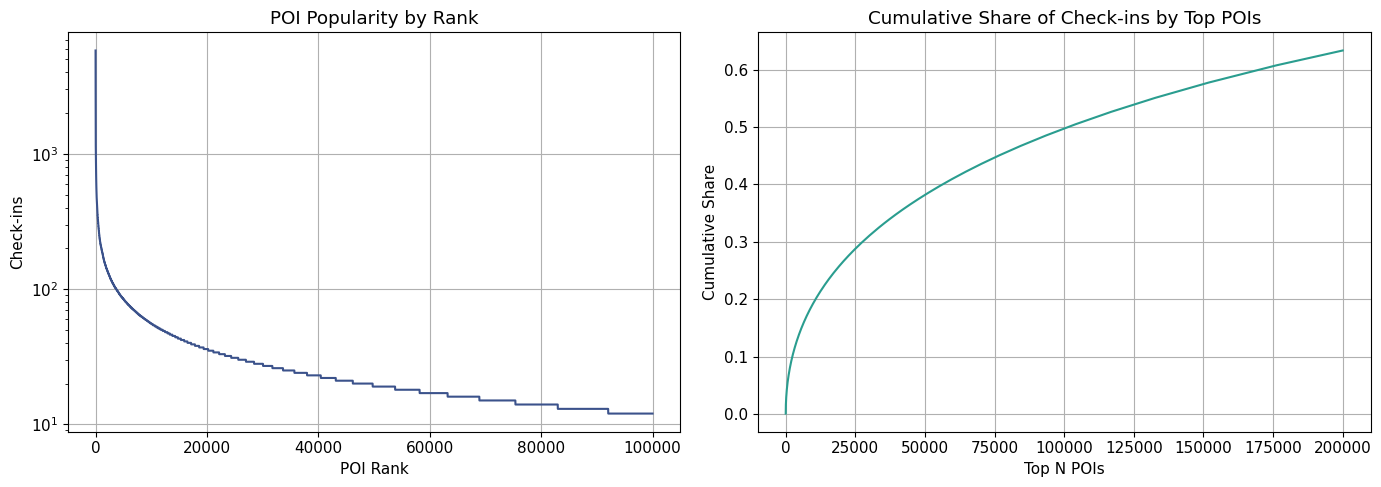

POIs needed for 25% of check-ins: 17,886
POIs needed for 50% of check-ins: 101,432
POIs needed for 75% of check-ins: 346,882
POIs needed for 90% of check-ins: 709,806


In [ ]:
# POI popularity long tail.

poi_popularity = place_base.sort_values("checkins", ascending=False).copy()
poi_popularity["rank"] = np.arange(1, len(poi_popularity) + 1)
poi_popularity["cumulative_checkins"] = poi_popularity["checkins"].cumsum()
poi_popularity["cumulative_share"] = (
    poi_popularity["cumulative_checkins"] / poi_popularity["checkins"].sum()
)

display(poi_popularity.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=poi_popularity.head(100_000),
    x="rank",
    y="checkins",
    ax=axes[0],
    color="#3b528b",
)

axes[0].set_title("POI Popularity by Rank")
axes[0].set_xlabel("POI Rank")
axes[0].set_ylabel("Check-ins")
axes[0].set_yscale("log")

sns.lineplot(
    data=poi_popularity.head(200_000),
    x="rank",
    y="cumulative_share",
    ax=axes[1],
    color="#2a9d8f",
)

axes[1].set_title("Cumulative Share of Check-ins by Top POIs")
axes[1].set_xlabel("Top N POIs")
axes[1].set_ylabel("Cumulative Share")

plt.tight_layout()
plt.savefig(FIG_DIR / "poi_popularity_long_tail.png", dpi=160, bbox_inches="tight")
plt.show()

for threshold in [0.25, 0.50, 0.75, 0.90]:
    n_pois = int((poi_popularity["cumulative_share"] <= threshold).sum() + 1)
    print(f"POIs needed for {threshold:.0%} of check-ins: {n_pois:,}")

,userid,checkins,unique_pois,unique_categories,active_days,first_seen,last_seen,activity_span_days,checkins_per_active_day,repeat_checkins,repeat_share
55001,97712,50,1,1,50,2010-07-02 22:26:09+00:00,2010-10-12 21:12:18+00:00,102,1.0000,49,0.9800
85420,147035,64,2,2,63,2010-03-09 13:42:01+00:00,2010-09-28 12:45:36+00:00,203,1.0159,62,0.9688
5771,6972,25,1,1,24,2010-06-28 21:02:22+00:00,2010-10-22 06:42:36+00:00,116,1.0417,24,0.9600
38904,61824,75,3,2,19,2010-07-26 05:08:36+00:00,2010-09-17 05:09:50+00:00,54,3.9474,72,0.9600
70347,119964,49,2,2,25,2009-11-24 20:10:21+00:00,2010-02-23 15:30:40+00:00,91,1.9600,47,0.9592
67058,114958,39,2,2,33,2009-12-16 14:27:29+00:00,2010-03-23 13:01:54+00:00,97,1.1818,37,0.9487
72443,123397,18,1,1,18,2010-07-12 08:38:32+00:00,2010-08-31 06:56:24+00:00,50,1.0000,17,0.9444
92342,160731,53,3,3,45,2010-02-21 23:47:05+00:00,2010-10-09 22:21:52+00:00,230,1.1778,50,0.9434
93757,164787,53,3,3,37,2010-04-15 06:56:05+00:00,2010-09-20 06:50:17+00:00,158,1.4324,50,0.9434
24634,36805,35,2,2,35,2010-04-08 17:00:09+00:00,2010-10-10 10:06:42+00:00,185,1.0000,33,0.9429


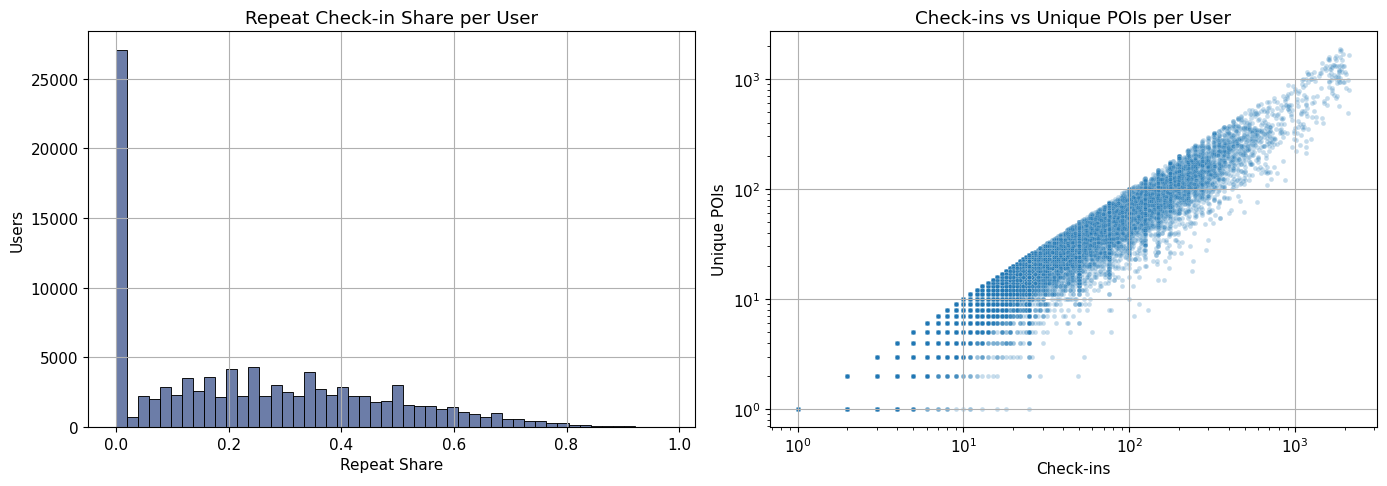

In [ ]:
# Repeat behavior: do users return to the same places or mostly explore new POIs?

user_repeat = user_activity.copy()
user_repeat["repeat_checkins"] = user_repeat["checkins"] - user_repeat["unique_pois"]
user_repeat["repeat_share"] = user_repeat["repeat_checkins"] / user_repeat["checkins"]

display(user_repeat.sort_values("repeat_share", ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(user_repeat["repeat_share"], bins=50, ax=axes[0], color="#3b528b")
axes[0].set_title("Repeat Check-in Share per User")
axes[0].set_xlabel("Repeat Share")
axes[0].set_ylabel("Users")

sns.scatterplot(
    data=user_repeat.sample(min(30_000, len(user_repeat)), random_state=RANDOM_STATE),
    x="checkins",
    y="unique_pois",
    alpha=0.25,
    s=12,
    ax=axes[1],
)

axes[1].set_title("Check-ins vs Unique POIs per User")
axes[1].set_xlabel("Check-ins")
axes[1].set_ylabel("Unique POIs")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(FIG_DIR / "repeat_vs_exploration.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
# Build user-level transitions: previous check-in -> current check-in.

def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2.astype(float))
    lon2 = np.radians(lon2.astype(float))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0088 * c

transition_cols = [
    "userid",
    "datetime",
    "placeid",
    "lat",
    "lng",
    "category_name",
    "hour",
    "weekday",
]

seq_df = df[transition_cols].sort_values(["userid", "datetime", "placeid"]).copy()

for col in ["placeid", "datetime", "lat", "lng", "category_name"]:
    seq_df[f"prev_{col}"] = seq_df.groupby("userid", sort=False)[col].shift(1)

transitions = seq_df[seq_df["prev_placeid"].notna()].copy()

transitions["delta_hours"] = (
    transitions["datetime"] - transitions["prev_datetime"]
).dt.total_seconds() / 3600

transitions = transitions[transitions["delta_hours"] >= 0].copy()

transitions["distance_km"] = haversine_km(
    transitions["prev_lat"],
    transitions["prev_lng"],
    transitions["lat"],
    transitions["lng"],
)

transitions["is_self_loop"] = transitions["prev_placeid"] == transitions["placeid"]

del seq_df

transition_summary = pd.DataFrame({
    "metric": [
        "transitions",
        "self_loop_share",
        "median_delta_hours",
        "p90_delta_hours",
        "median_distance_km",
        "p90_distance_km",
        "transitions_under_24h_share",
        "transitions_under_7d_share",
    ],
    "value": [
        len(transitions),
        transitions["is_self_loop"].mean(),
        transitions["delta_hours"].median(),
        transitions["delta_hours"].quantile(0.90),
        transitions["distance_km"].median(),
        transitions["distance_km"].quantile(0.90),
        (transitions["delta_hours"] <= 24).mean(),
        (transitions["delta_hours"] <= 168).mean(),
    ],
})

display(transition_summary)
display(transitions.head())

,metric,value
0,transitions,"6,335,170.0000"
1,self_loop_share,0.0398
2,median_delta_hours,4.5957
3,p90_delta_hours,71.6600
4,median_distance_km,2.0506
5,p90_distance_km,41.8738
6,transitions_under_24h_share,0.7587
7,transitions_under_7d_share,0.9605


,userid,datetime,placeid,lat,lng,category_name,hour,weekday,prev_placeid,prev_datetime,prev_lat,prev_lng,prev_category_name,delta_hours,distance_km,is_self_loop
1,0,2010-05-22 17:50:55+00:00,8977,39.2974,-94.7160,Airport,17,Saturday,"608,105.0000",2010-05-22 02:49:04+00:00,30.2489,-97.7496,Pizza,15.0308,"1,043.4153",False
2,0,2010-05-22 19:13:12+00:00,18574,38.9852,-94.6059,BBQ,19,Saturday,"8,977.0000",2010-05-22 17:50:55+00:00,39.2974,-94.7160,Airport,1.3714,35.9908,False
3,0,2010-05-23 16:50:50+00:00,17269,39.0935,-94.5932,American,16,Sunday,"18,574.0000",2010-05-22 19:13:12+00:00,38.9852,-94.6059,BBQ,21.6272,12.0912,False
4,0,2010-05-23 17:51:57+00:00,1161876,39.0933,-94.5939,Snow Cones,17,Sunday,"17,269.0000",2010-05-23 16:50:50+00:00,39.0935,-94.5932,American,1.0186,0.0673,False
5,0,2010-05-23 22:40:45+00:00,1163401,39.0004,-94.5777,Watch Party,22,Sunday,"1,161,876.0000",2010-05-23 17:51:57+00:00,39.0933,-94.5939,Snow Cones,4.8133,10.4141,False


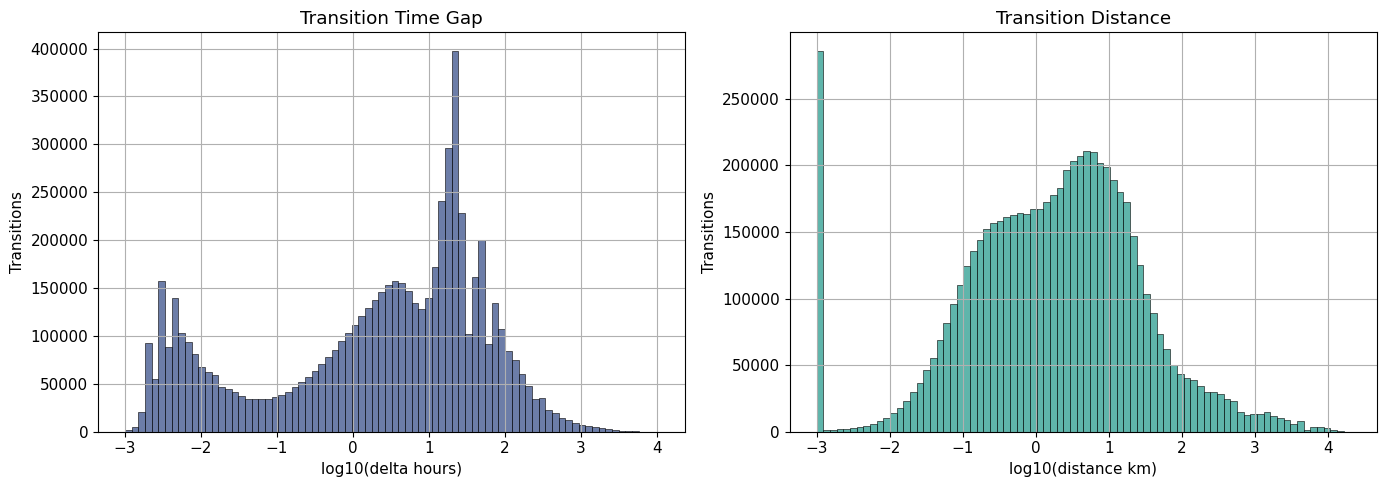

In [ ]:
# Transition time and distance distributions.

plot_transitions = transitions[
    (transitions["delta_hours"] > 0)
    & transitions["distance_km"].notna()
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    np.log10(plot_transitions["delta_hours"].clip(lower=1e-3)),
    bins=80,
    ax=axes[0],
    color="#3b528b",
)

axes[0].set_title("Transition Time Gap")
axes[0].set_xlabel("log10(delta hours)")
axes[0].set_ylabel("Transitions")

sns.histplot(
    np.log10(plot_transitions["distance_km"].clip(lower=1e-3)),
    bins=80,
    ax=axes[1],
    color="#2a9d8f",
)

axes[1].set_title("Transition Distance")
axes[1].set_xlabel("log10(distance km)")
axes[1].set_ylabel("Transitions")

plt.tight_layout()
plt.savefig(FIG_DIR / "transition_time_distance_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

category_name,Corporate Office,Coffee Shop,Grocery,Apartment,Train Station,Mall,Gas & Automotive,American,Asian,Mexican,Other - Food,Airport,Pub,Starbucks,Other - Shopping
category_name,,,,,,,,,,,,,,,
Corporate Office,39856,6590,4887,8996,5711,3721,3912,3496,5342,4171,6114,1966,3660,3052,1563
Coffee Shop,7978,11727,3390,2776,2196,2648,1688,2191,3141,2702,2866,1341,2609,1799,1817
Grocery,4793,2988,6802,4525,1552,2343,3764,1701,2068,1748,1645,535,1224,2401,1864
Apartment,10415,2717,2927,14449,2042,2219,2056,850,1253,860,1683,685,1095,800,834
Train Station,6167,2413,1631,2103,45521,1811,703,322,1061,213,1258,1321,1367,976,846
Mall,2578,3036,3262,2198,1429,6399,1401,1716,2387,1143,2220,637,877,2225,2502
Gas & Automotive,4441,1602,4043,2173,713,1921,10104,2269,1615,2227,1400,628,684,1655,1476
American,2968,2345,1994,1008,338,1582,2441,3888,1558,2373,1261,1464,1429,2100,1231
Asian,4160,3417,2403,1505,1028,2087,1598,1640,5449,1574,1693,790,1500,1887,1305


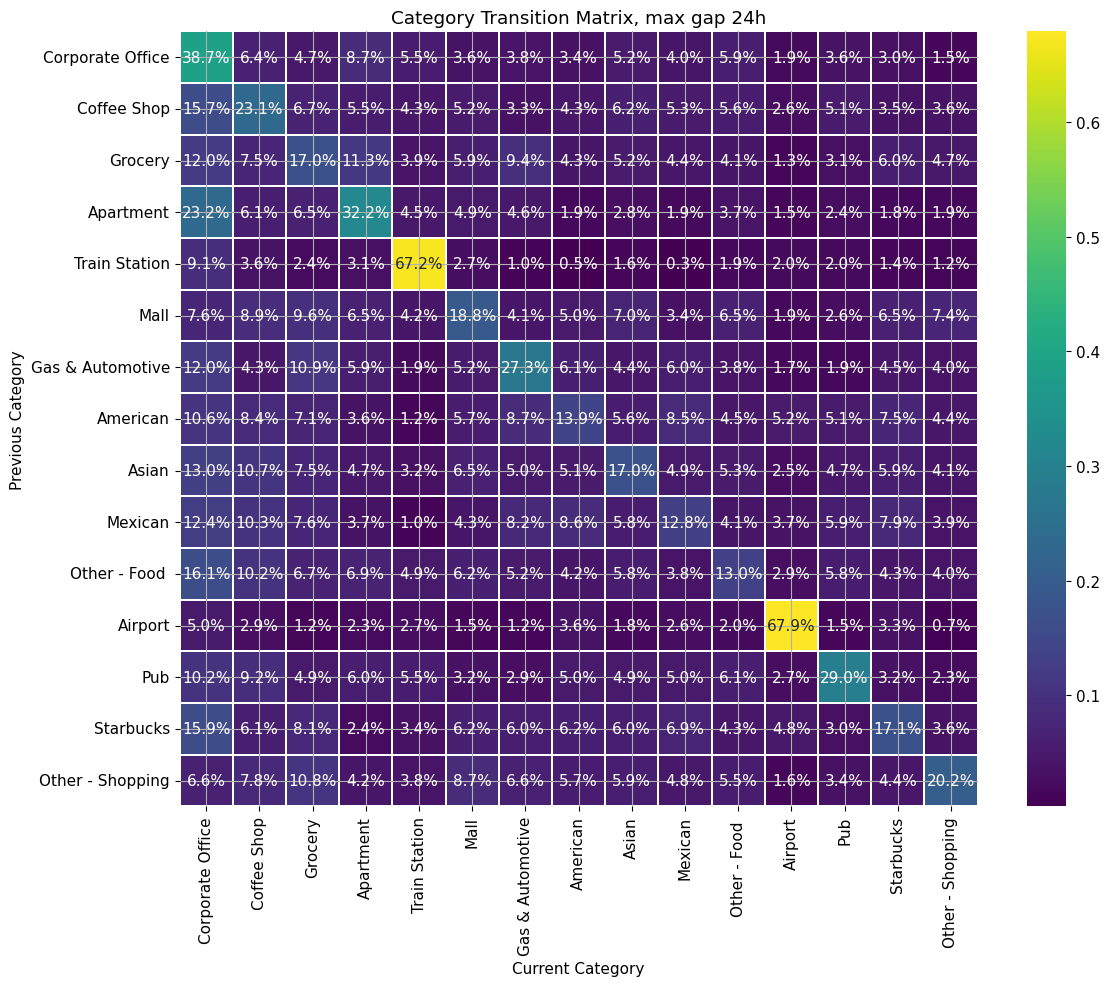

In [ ]:
# Category-to-category transitions within a reasonable time window.

MAX_TRANSITION_GAP_HOURS = 24
top_n_categories = 15

category_transition_data = transitions[
    (transitions["delta_hours"] <= MAX_TRANSITION_GAP_HOURS)
    & (transitions["prev_category_name"].astype(str) != "Unknown")
    & (transitions["category_name"].astype(str) != "Unknown")
].copy()

category_transition_data["prev_category_name"] = (
    category_transition_data["prev_category_name"].astype(str)
)

category_transition_data["category_name"] = (
    category_transition_data["category_name"].astype(str)
)

top_transition_categories = (
    df.loc[df["category_name"].astype(str) != "Unknown", "category_name"]
    .astype(str)
    .value_counts()
    .head(top_n_categories)
    .index
)

category_transition_data = category_transition_data[
    category_transition_data["prev_category_name"].isin(top_transition_categories)
    & category_transition_data["category_name"].isin(top_transition_categories)
]

category_transition_matrix = pd.crosstab(
    category_transition_data["prev_category_name"],
    category_transition_data["category_name"],
)

category_transition_matrix = (
    category_transition_matrix
    .reindex(index=top_transition_categories, columns=top_transition_categories)
    .fillna(0)
)

category_transition_row_norm = category_transition_matrix.div(
    category_transition_matrix.sum(axis=1),
    axis=0,
).fillna(0)

display(category_transition_matrix.astype(int))

plt.figure(figsize=(12, 10))

sns.heatmap(
    category_transition_row_norm,
    cmap="viridis",
    linewidths=0.3,
    linecolor="white",
    annot=True,
    fmt=".1%",
)

plt.title(f"Category Transition Matrix, max gap {MAX_TRANSITION_GAP_HOURS}h")
plt.xlabel("Current Category")
plt.ylabel("Previous Category")

plt.tight_layout()
plt.savefig(FIG_DIR / "category_transition_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

,month,checkins,active_users,active_pois,top_poi_jaccard_vs_prev,top_poi_jaccard_vs_first,top_category_jaccard_vs_prev,top_category_jaccard_vs_first
0,2009-02,7,2,6,1.0000,1.0000,1.0000,1.0000
1,2009-03,873,82,317,0.0000,0.0000,0.0286,0.0286
2,2009-04,567,71,383,0.0363,0.0192,0.2766,0.0286
3,2009-05,998,84,676,0.0753,0.0291,0.4286,0.0286
4,2009-06,675,89,482,0.0753,0.0192,0.5385,0.0588
5,2009-07,1102,135,902,0.1050,0.0192,0.5385,0.0286
6,2009-08,1442,149,1077,0.0582,0.0095,0.6216,0.0000
7,2009-09,7641,711,4700,0.0471,0.0000,0.6667,0.0000
8,2009-10,37884,2241,19490,0.2658,0.0000,0.6667,0.0000
9,2009-11,86863,4973,43022,0.1976,0.0000,0.7143,0.0000


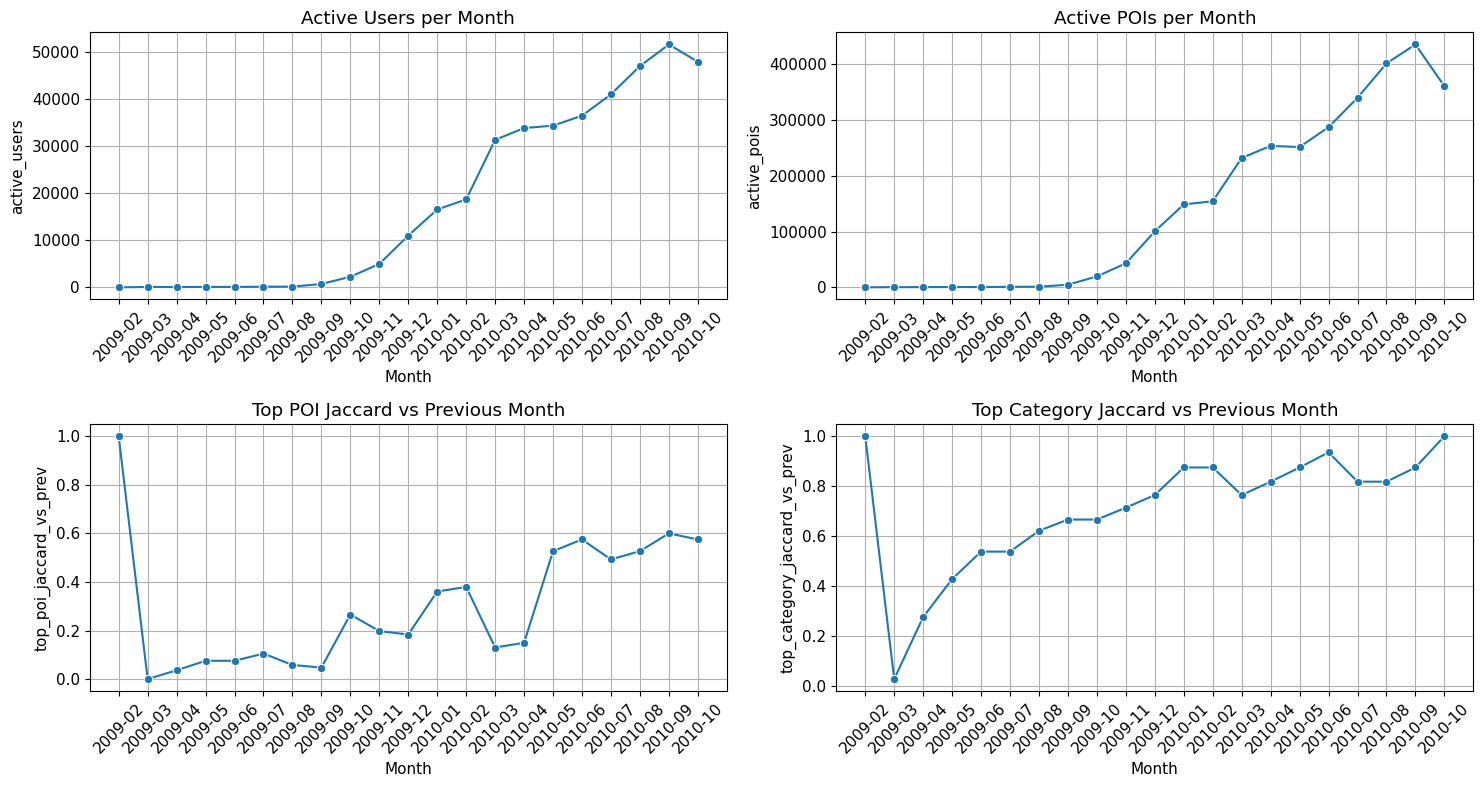

In [ ]:
# Temporal drift: how stable are popular POIs and categories over months?

if "month" not in df.columns:
    df["month"] = df["datetime"].dt.to_period("M").astype(str)

def jaccard(a, b):
    a = set(a)
    b = set(b)
    if not a and not b:
        return np.nan
    return len(a & b) / len(a | b)

periods = sorted(df["month"].unique())
TOP_K_POIS = 100
TOP_K_CATEGORIES = 30

drift_rows = []

first_period = periods[0]
first_df = df[df["month"] == first_period]

first_top_pois = first_df["placeid"].value_counts().head(TOP_K_POIS).index
first_top_categories = (
    first_df["category_name"].astype(str)
    .value_counts()
    .head(TOP_K_CATEGORIES)
    .index
)

for i, period in enumerate(periods):
    cur = df[df["month"] == period]

    cur_top_pois = cur["placeid"].value_counts().head(TOP_K_POIS).index
    cur_top_categories = (
        cur["category_name"].astype(str)
        .value_counts()
        .head(TOP_K_CATEGORIES)
        .index
    )

    if i == 0:
        prev_top_pois = cur_top_pois
        prev_top_categories = cur_top_categories
    else:
        prev = df[df["month"] == periods[i - 1]]
        prev_top_pois = prev["placeid"].value_counts().head(TOP_K_POIS).index
        prev_top_categories = (
            prev["category_name"].astype(str)
            .value_counts()
            .head(TOP_K_CATEGORIES)
            .index
        )

    drift_rows.append({
        "month": period,
        "checkins": len(cur),
        "active_users": cur["userid"].nunique(),
        "active_pois": cur["placeid"].nunique(),
        "top_poi_jaccard_vs_prev": jaccard(cur_top_pois, prev_top_pois),
        "top_poi_jaccard_vs_first": jaccard(cur_top_pois, first_top_pois),
        "top_category_jaccard_vs_prev": jaccard(cur_top_categories, prev_top_categories),
        "top_category_jaccard_vs_first": jaccard(cur_top_categories, first_top_categories),
    })

temporal_drift = pd.DataFrame(drift_rows)

display(temporal_drift)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

sns.lineplot(data=temporal_drift, x="month", y="active_users", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Active Users per Month")

sns.lineplot(data=temporal_drift, x="month", y="active_pois", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Active POIs per Month")

sns.lineplot(data=temporal_drift, x="month", y="top_poi_jaccard_vs_prev", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Top POI Jaccard vs Previous Month")

sns.lineplot(data=temporal_drift, x="month", y="top_category_jaccard_vs_prev", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Top Category Jaccard vs Previous Month")

for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Month")

plt.tight_layout()
plt.savefig(FIG_DIR / "temporal_drift_summary.png", dpi=160, bbox_inches="tight")
plt.show()

## EDA Summary and Main Findings

This notebook analyzes the full SNAP Gowalla check-in dataset enriched with Gowalla POI metadata from Figshare.

Main findings:

1. **Metadata coverage**
   - The original SNAP Gowalla check-in file contains user IDs, timestamps, coordinates, and `placeid`.
   - It does not contain POI names or categories.
   - Figshare metadata provides category information for most POIs/check-ins.
   - POI names are available only for a small subset, so category-level analysis is more reliable than spot-name-level analysis.

2. **Activity distribution**
   - User activity is highly long-tailed: most users have relatively few check-ins, while a small group is very active.
   - POI popularity is also long-tailed: a relatively small fraction of POIs accounts for a large share of all check-ins.

3. **Temporal patterns**
   - Check-in activity varies by hour, weekday, and month.
   - Row-normalized weekday-hour heatmaps show different daily rhythms across weekdays.
   - Category-hour profiles show that different POI categories dominate at different times of day.

4. **Spatial patterns**
   - The global Folium heatmap shows that Gowalla activity is concentrated in several major regions, especially North America and Europe.
   - The dataset is global, not limited to New York.

5. **Sequential behavior**
   - User trajectories can be represented as transitions from one POI to the next.
   - Transition time gaps and distances are important for deciding whether all observed transitions should be used or whether a maximum time window should be applied.
   - Category transition matrices reveal common movement patterns between types of places.

6. **Temporal drift**
   - Monthly activity, active users, active POIs, and top-POI stability change over time.
   - This suggests that future modeling should use a temporal train/validation/test split instead of a random split.

Overall, this EDA shows that Gowalla is suitable for location-based recommendation and POI transition analysis, but the modeling stage should account for long-tail sparsity, temporal drift, and incomplete POI name metadata.